# TP1

In [1]:
from src.utils import retrieve_patterns
from src.hopfield import Hopfield
from collections import defaultdict

shapes = {}
patterns = {}

for P, shape in retrieve_patterns("images"):
    n = P.shape[1]
    patterns[n] = P
    shapes[n] = shape

models = {}
for n, P in patterns.items():
    models[n] = m = Hopfield(n)
    m.train(P)

Parto el dataset de patrones en 2, entrenando un modelo para cada set de datos con distintas dimensiones

## Imágenes

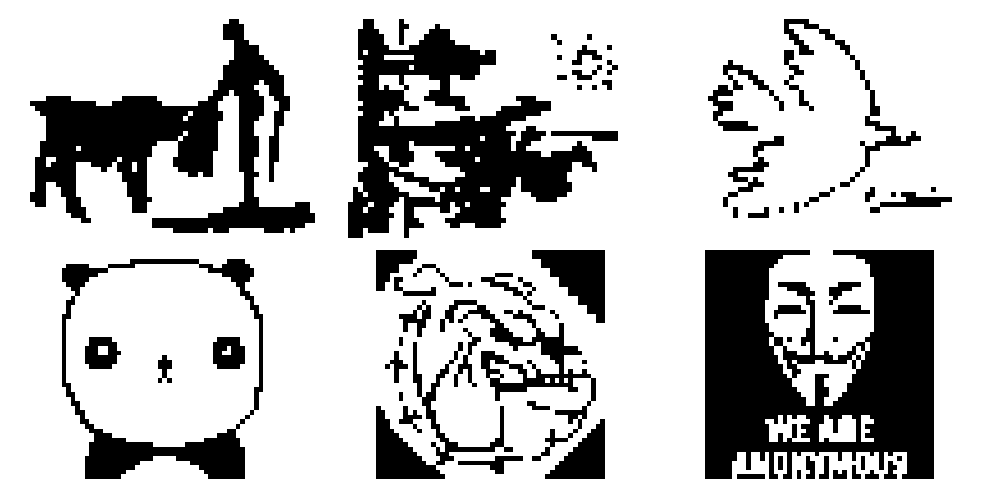

In [2]:
import matplotlib.pyplot as plt
import numpy as np

images = [np.resize(p, shapes[n]) for n, P in patterns.items() for p in P]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

for ax, image in zip(axes.flat, images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1-a) Verifique si la red aprendió las imágenes enseñadas

In [3]:
for n, m in models.items():
    P = patterns[n]

    for p in P:
        if not m.is_stable(p):
            raise Exception(f"failed to learn pattern")

Dado que no tiró la excepción, podemos confirmar que los patrones son estados estables en sus respectivas redes, osea, las redes aprendieron las imágenes.

## 1-b) Evalúe la evolución de la red al presentarle versiones alteradas de las imágenes aprendidas: agregado de ruido, elementos borrados o agregados.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable


def recall_metrics(m: Hopfield, p: np.ndarray, p_prime: np.ndarray) -> tuple[int, int]:
    closest, steps = m.recall(p_prime)
    dist = np.sum(np.abs(closest - p))
    return closest, steps, dist


def plot_metrics(m: Hopfield, P: np.ndarray, f: Callable):
    n = P.shape[1]
    ks = np.arange(0, n + 1, n // 10)
    steps, dists = [0] * len(ks), [0] * len(ks)

    for p in P:
        imgs = []
        for j, k in enumerate(ks):
            closest, steps_taken, dist = recall_metrics(m, p, f(p, min(k, n)))
            imgs.append(np.reshape(closest, shapes[n]))
            steps[j] += steps_taken / len(ks)
            dists[j] += dist / len(ks)
        
        fig, axs = plt.subplots(1, 10, figsize=(15, 2))
        
        for j, (ax, img) in enumerate(zip(axs, imgs)):
            ax.imshow(img, cmap="gray")
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 7))

    ax0.plot(ks, dists)
    ax0.set_title("Hamming distance between original and recalled")
    ax0.set_xlabel("Amount of modified neurons")
    ax0.set_ylabel("Distance (neurons)")

    ax1.plot(ks, steps)
    ax1.set_title("Steps taken to converge to a stable state")
    ax1.set_xlabel("Amount of modified neurons")
    ax1.set_ylabel("Steps")

    fig.suptitle(f"Hopfield Network with {n} neurons", fontsize=14)
    plt.tight_layout()
    plt.show()

#### Neuronas invertidas

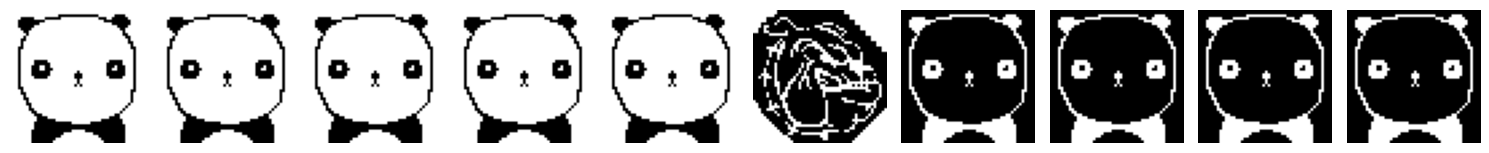

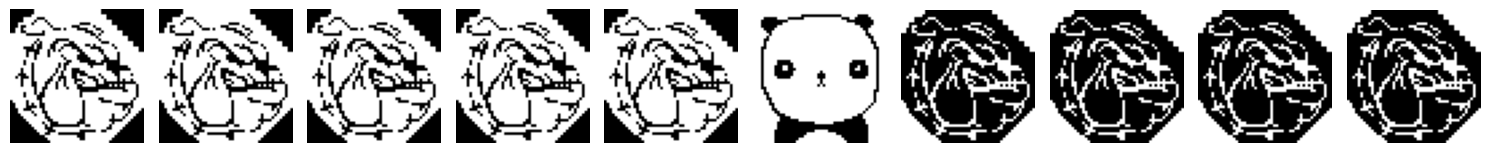

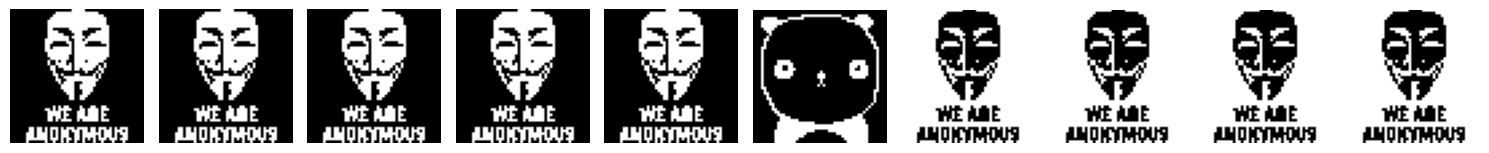

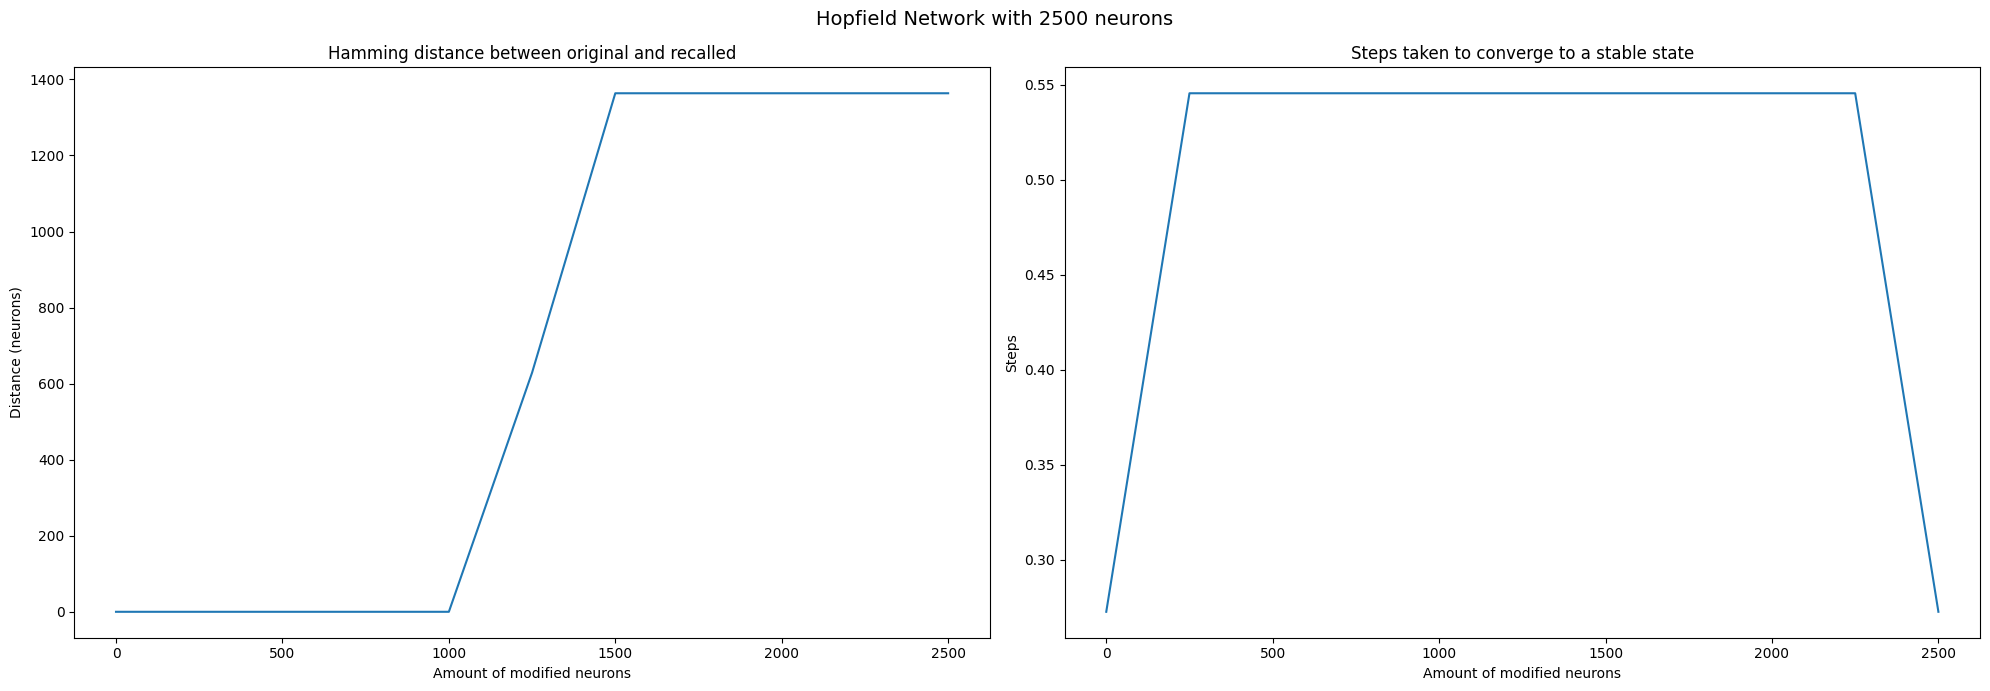

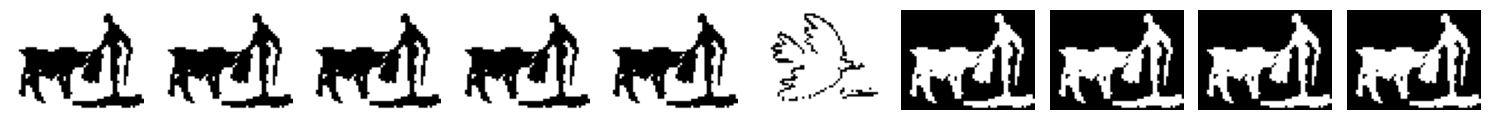

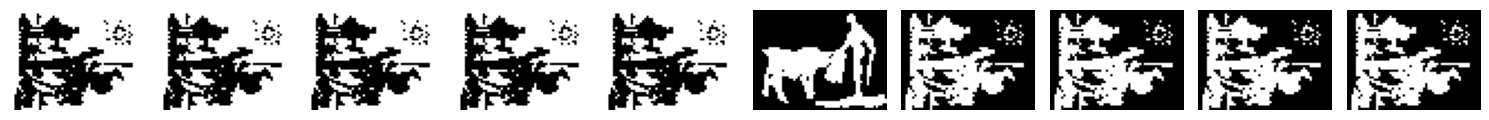

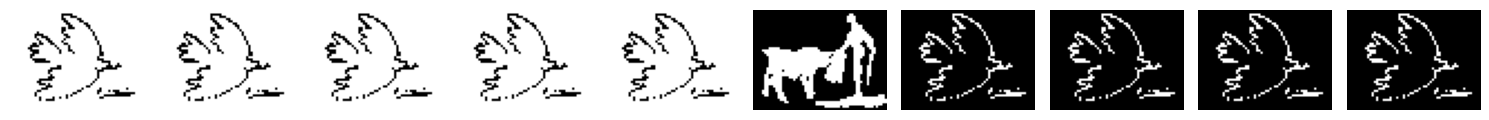

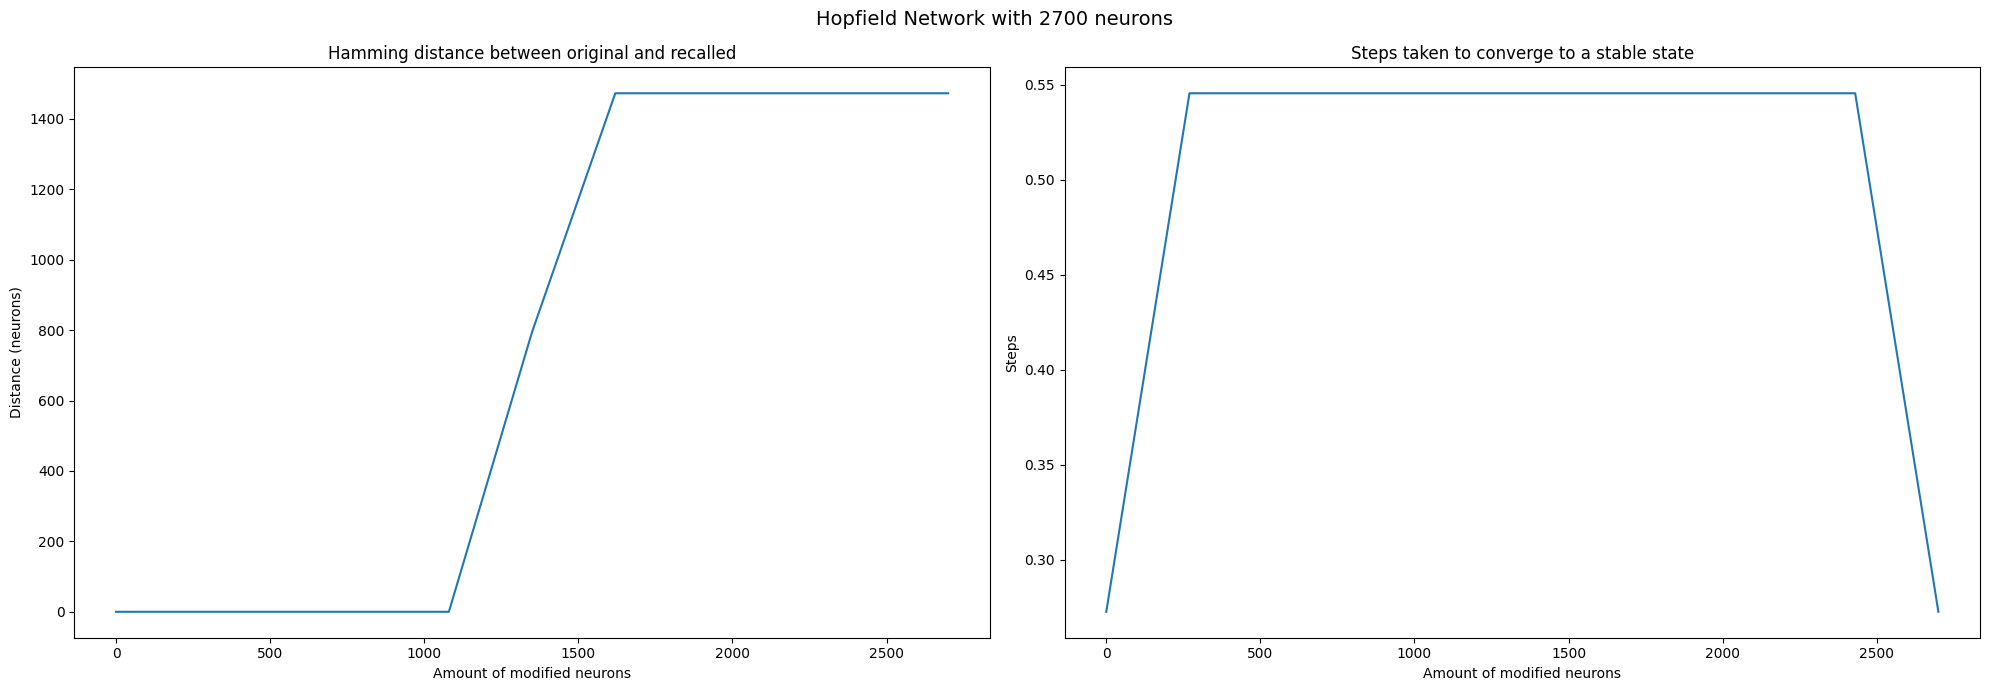

In [5]:
from src.utils import flip_bytes

for n in sorted(patterns):
    plot_metrics(models[n], patterns[n], flip_bytes)

#### Neuronas seteadas a 1

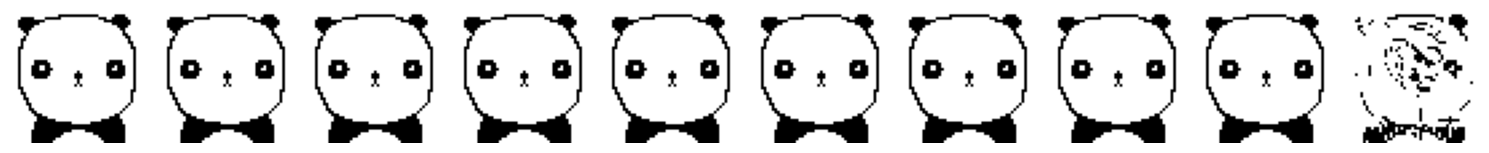

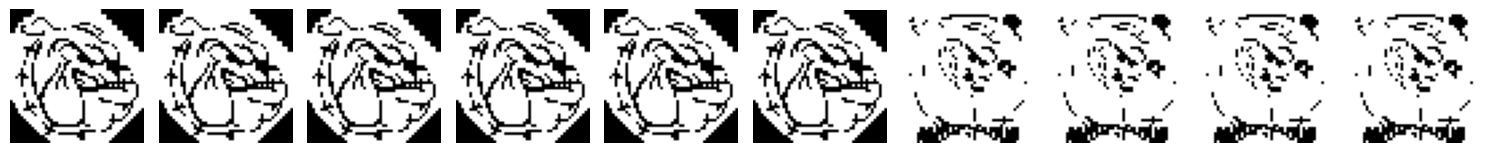

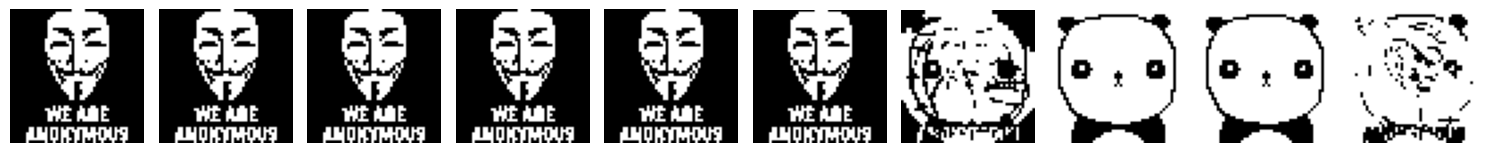

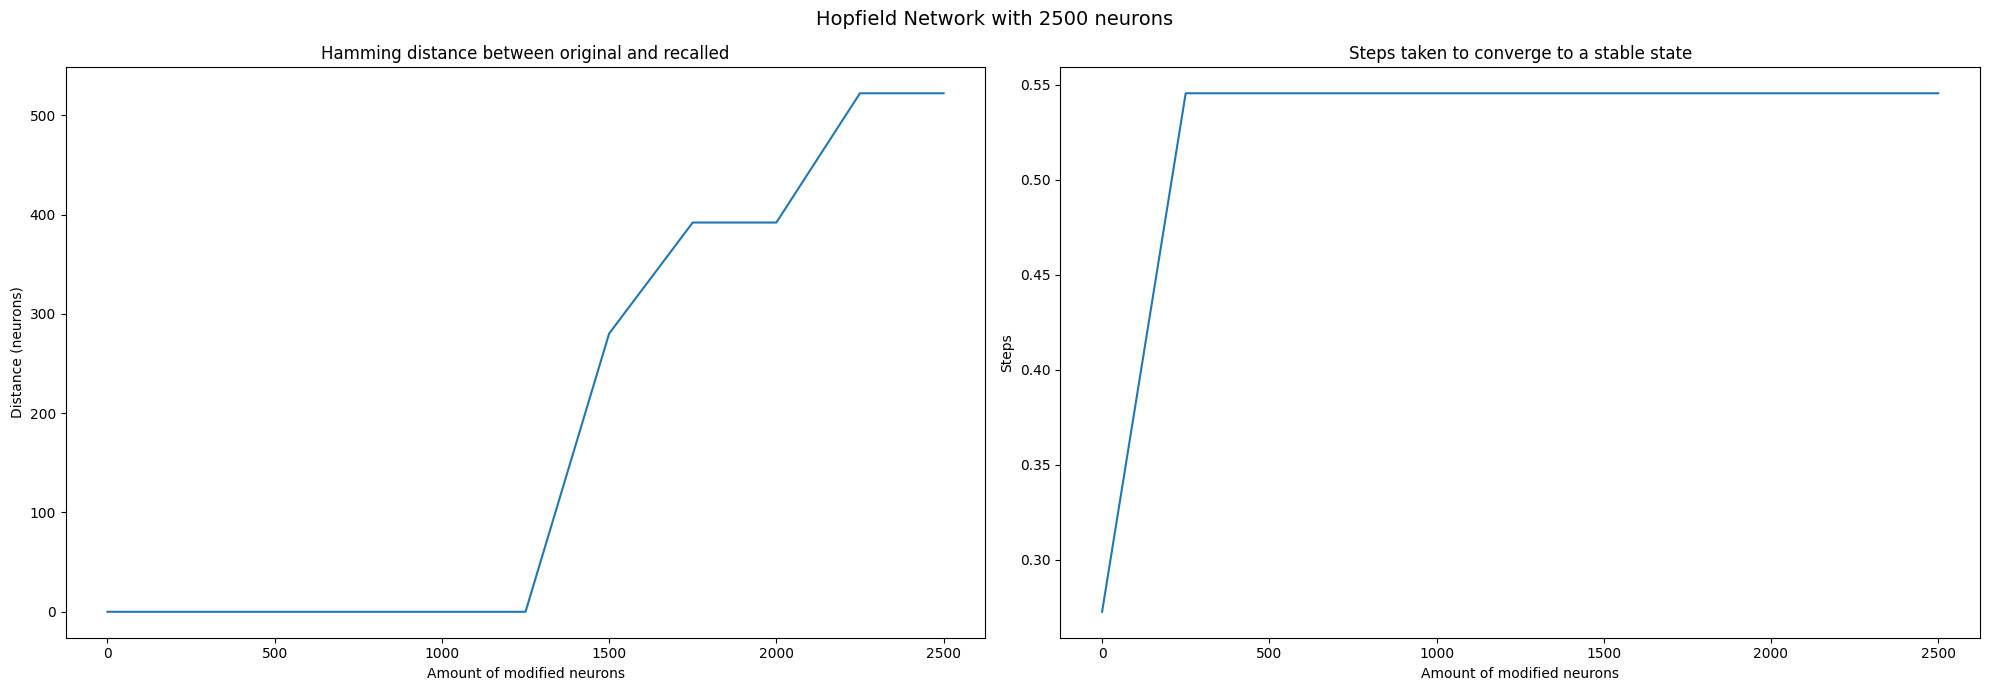

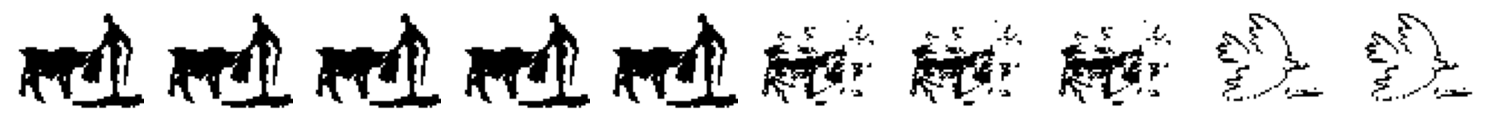

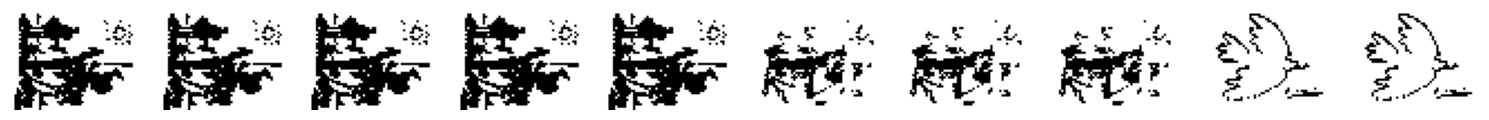

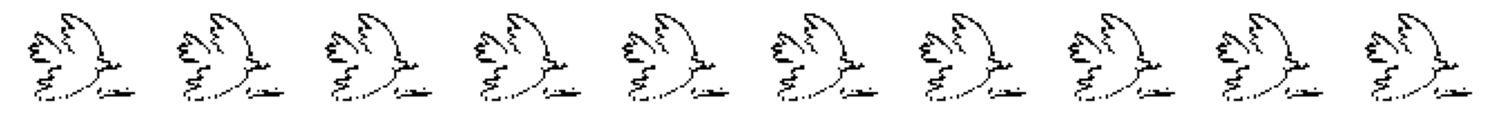

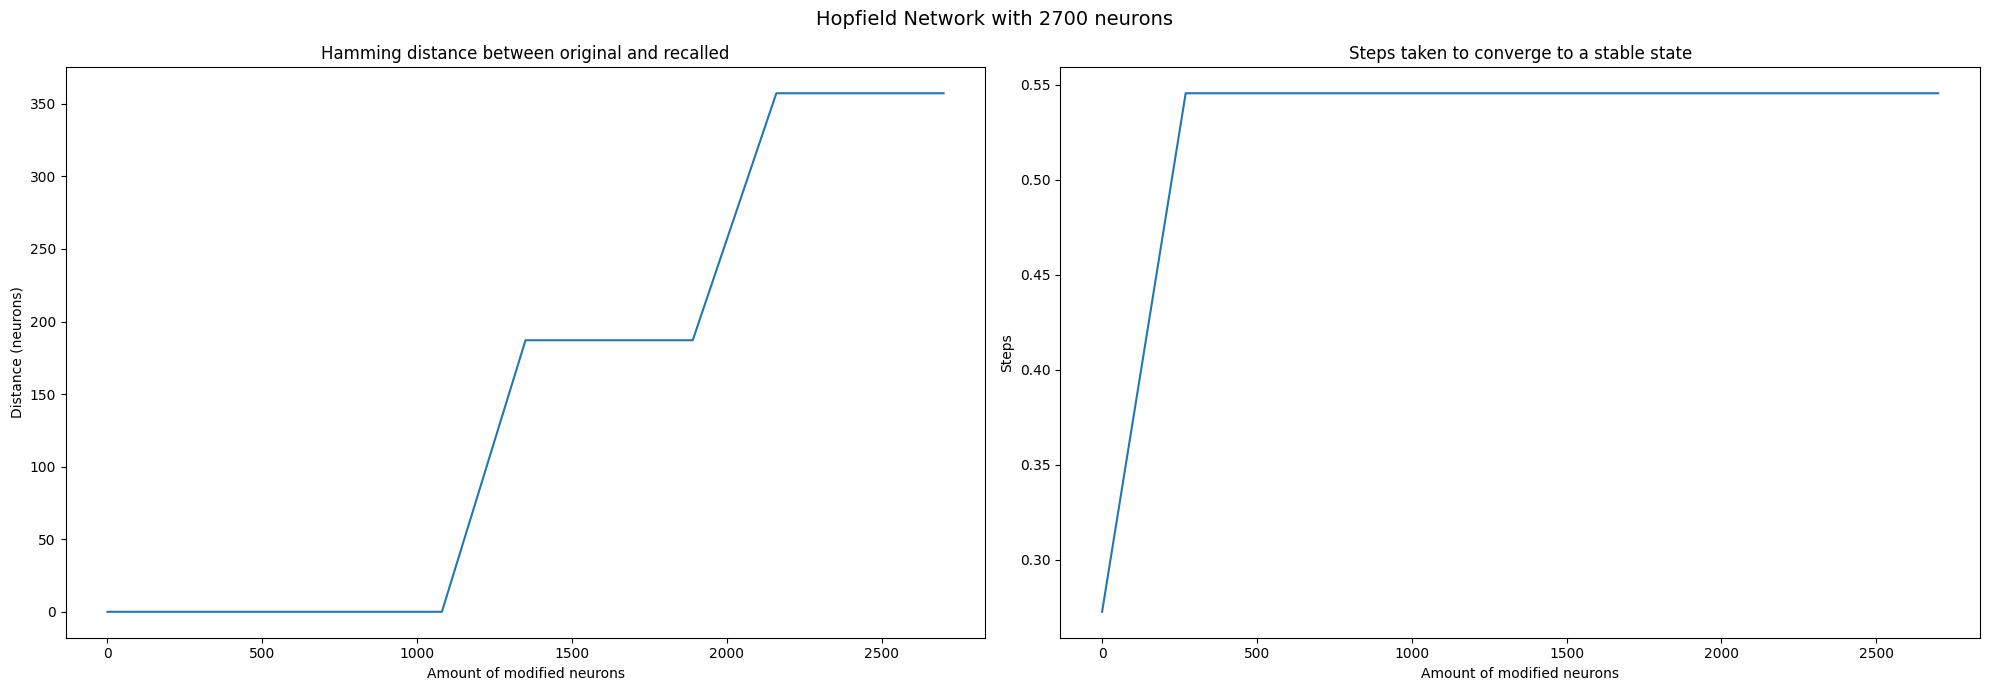

In [6]:
from src.utils import paint_bytes

for n in sorted(patterns):
    plot_metrics(models[n], patterns[n], lambda p, k: paint_bytes(p, k, 1))

#### Neuronas seteadas a -1

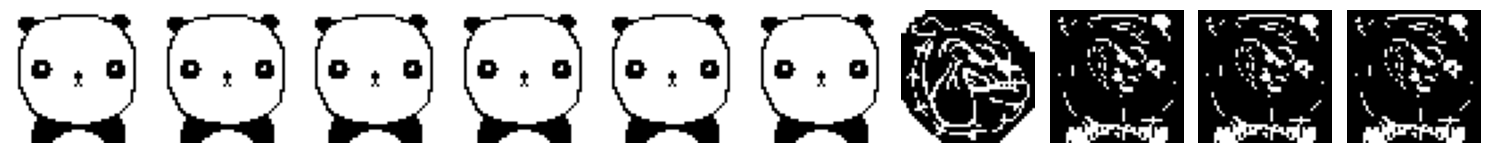

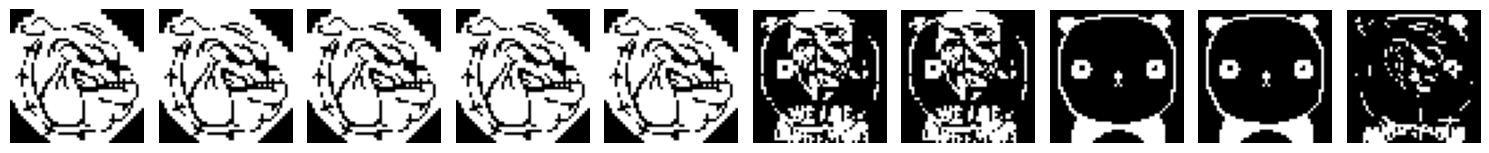

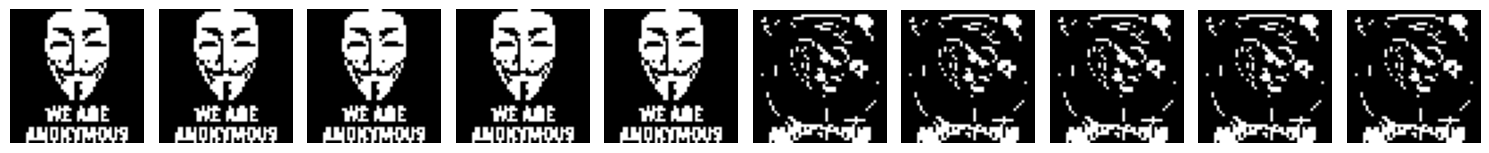

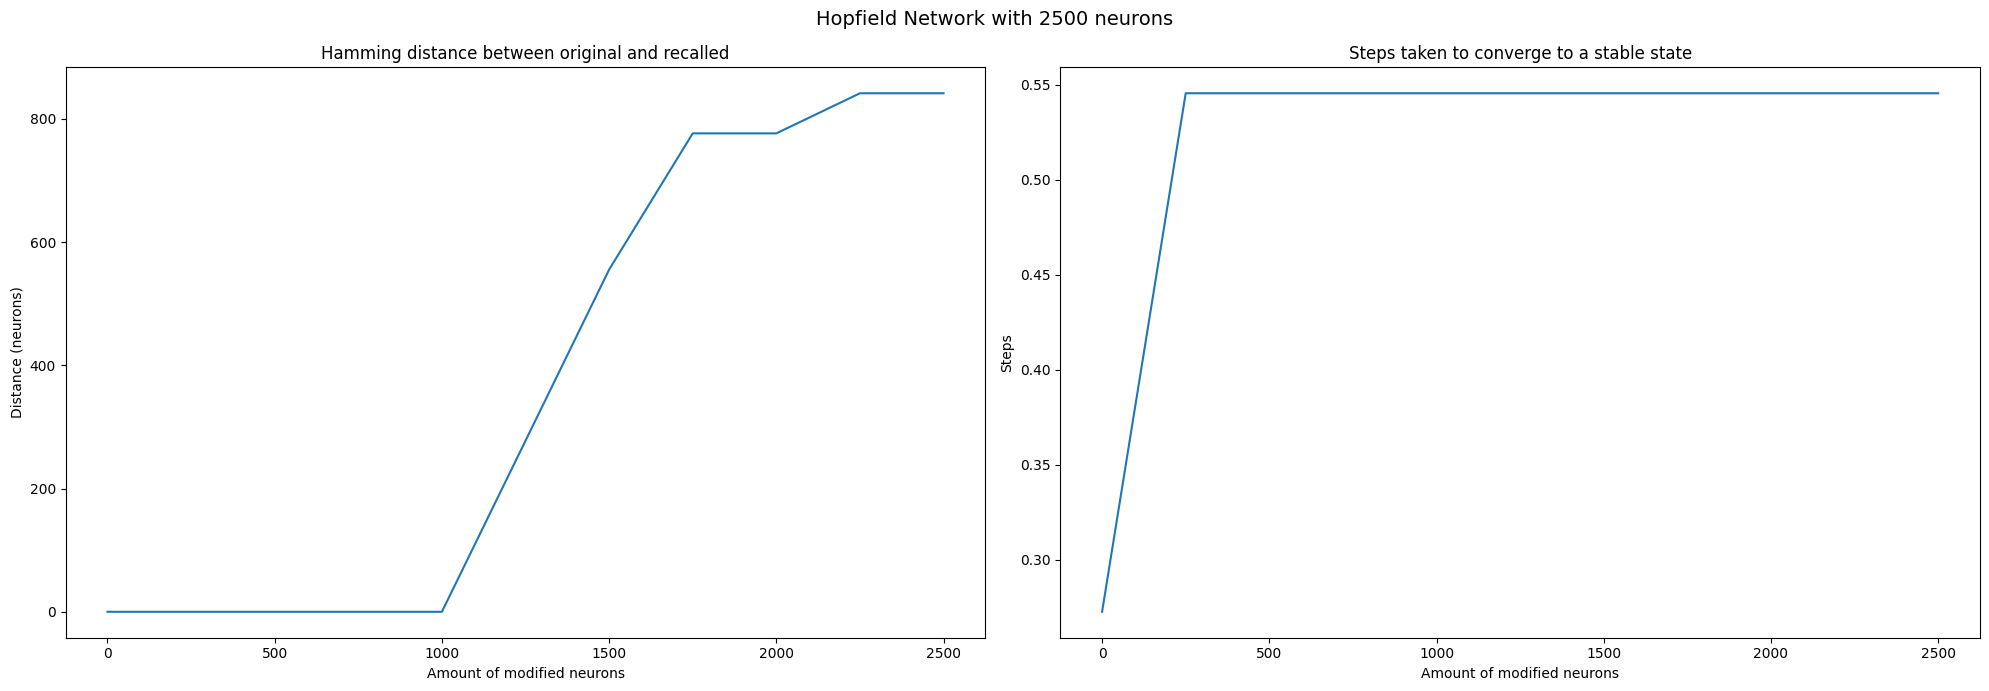

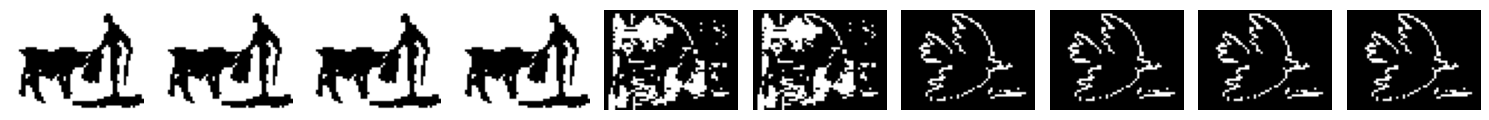

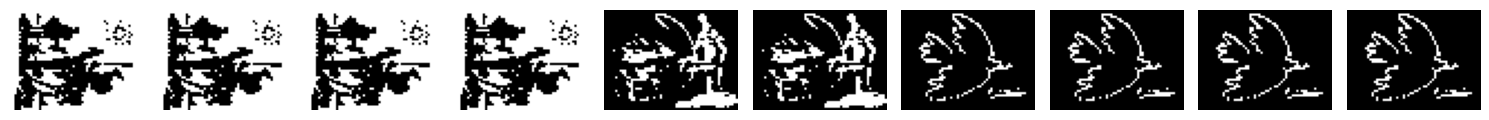

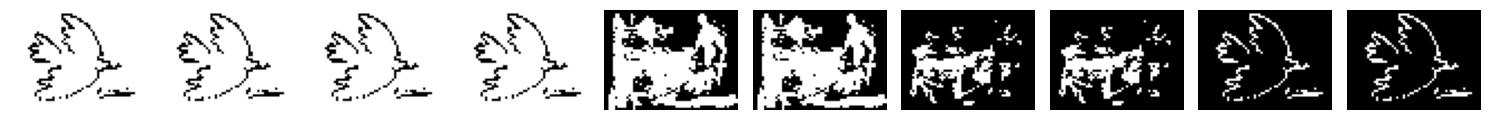

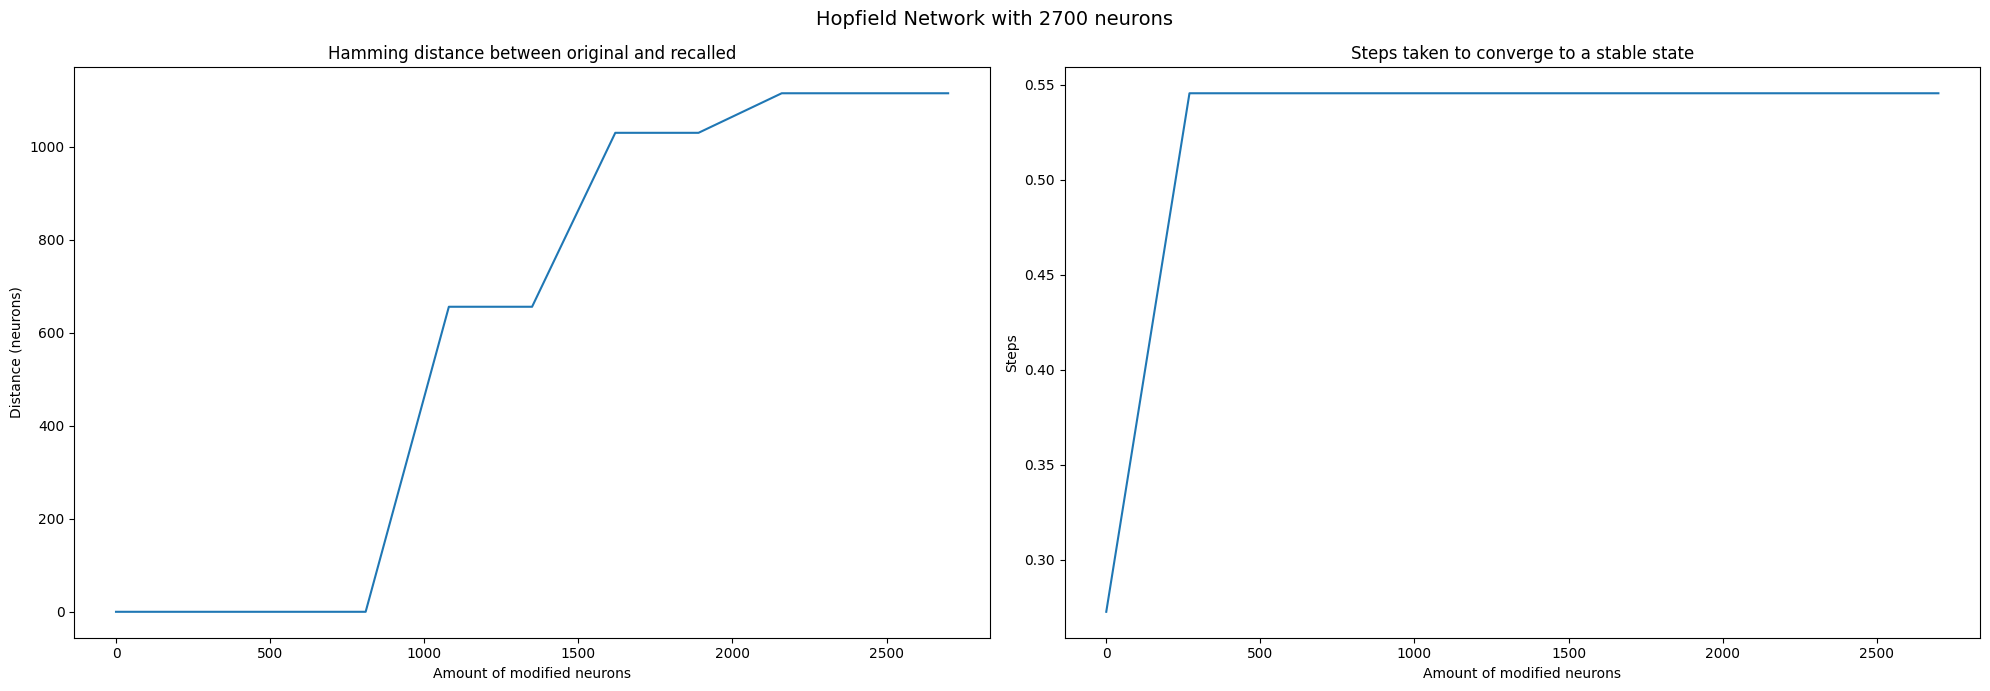

In [7]:
from src.utils import paint_bytes

for n in sorted(patterns):
    plot_metrics(models[n], patterns[n], lambda p, k: paint_bytes(p, k, -1))

Para el caso de invertir neuronas, ambas redes se comportan como esperado, una vez pasado el umbral de la mitad, el atractor inverso es más fuerte que el original, por lo que convergen hacia él.

Para los otros dos casos de tapar las imágenes con algún valor en particular, tiende a caer en otros estados espureos más particulares, se puede ver que algunos de ellos son combinaciones lineales de otros patrones aprendidos.

## 1-c) Evalúe la existencia de estados espurios en la red: patrones inversos y combinaciones de un número impar de patrones. (Ver Spurious States, en la sección 2.2, Hertz, Krogh & Palmer, pág. 24).

In [8]:
import numpy as np

def plot_patterns(Ps: list[np.ndarray], rows: int, cols: int):
    imgs = [np.reshape(p, shapes[len(p)]) for P in Ps for p in P]

    fig, axs = plt.subplots(rows, cols, figsize=(cols << 1, rows << 1))
    axs = np.array(axs).flatten()

    for j, (ax, img) in enumerate(zip(axs, imgs)):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

#### Patrones inversos

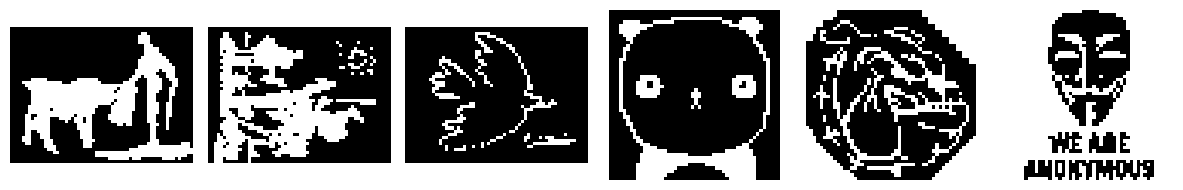

In [9]:
plot_patterns([-P for P in patterns.values()], 1, 6)

for n, m in models.items():
    P = -patterns[n]

    for p in P:
        if not m.is_stable(p):
            raise Exception("Inverse pattern is not a stable state")

#### Combinaciones de un número impar de patrones

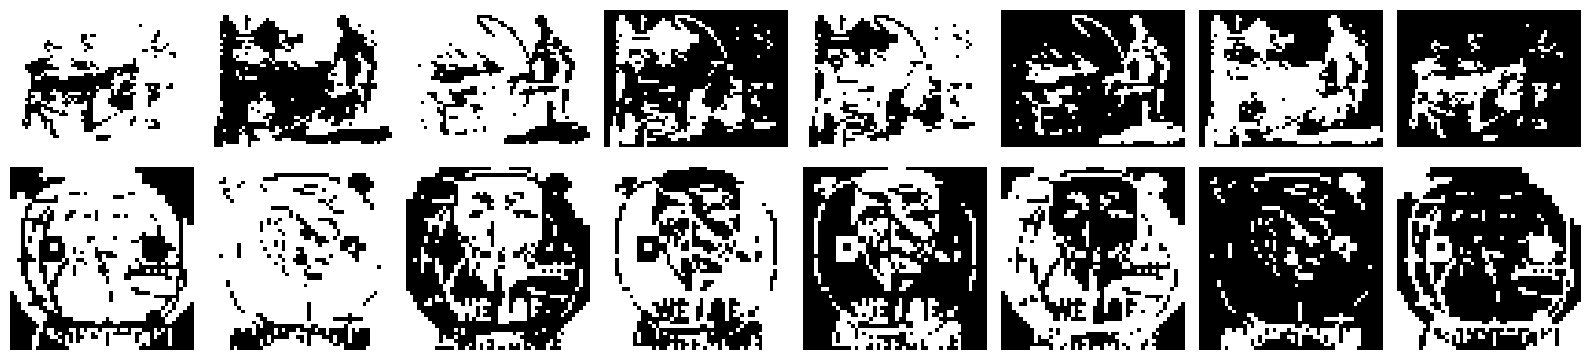

In [10]:
from src.utils import all_linear_combs

plot_patterns([all_linear_combs(P) for P in patterns.values()], 2, 8)

for n, m in models.items():
    combs = all_linear_combs(patterns[n])

    for p in combs:
        if not m.is_stable(p):
            raise Exception("Linear combination is not a stable state")

Para las combinaciones de patrones decidí usar todas las combinaciones y efectivamente todos ellos son estados estables en la red

## 1-d) Realice un entrenamiento con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique

AttributeError: 'numpy.ndarray' object has no attribute 'name'

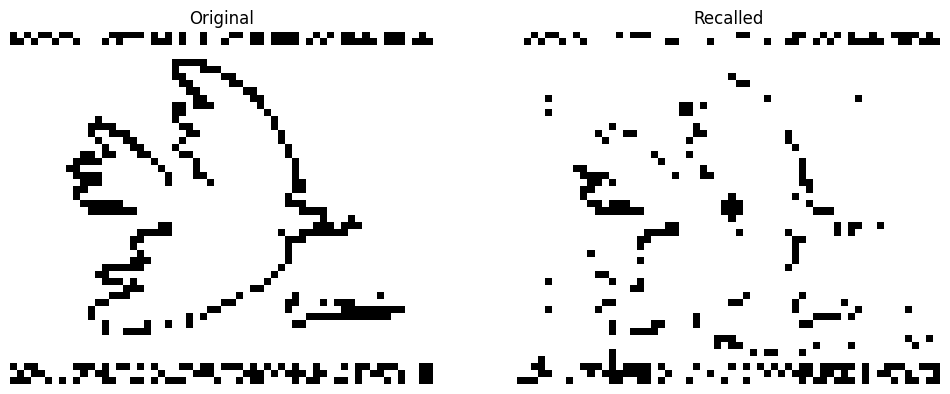

In [25]:
from src.utils import retrieve_patterns

import matplotlib.pyplot as plt
import numpy as np
from typing import Iterable

mheight = max(im.shape[0] for im in images)
mwidth = max(im.shape[1] for im in images)
shape = mwidth, mheight


def plot_if_different(m: Hopfield, p: np.ndarray):
    recalled, steps, dist = recall_metrics(m, p, p)
    if dist == 0:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    p_arr = p.reshape(shape)
    ax1.imshow((p_arr + 1) // 2, cmap="gray", interpolation="nearest")
    ax1.set_title("Original")
    ax1.axis("off")

    r_arr = recalled.reshape(shape)
    ax2.imshow((r_arr + 1) // 2, cmap="gray", interpolation="nearest")
    ax2.set_title(f"Recalled")
    ax2.axis("off")

    fig.suptitle(f"Took {steps} steps to reach a state with a Hamming distance of {dist} for {p.name}", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


m = Hopfield(mwidth * mheight)

P, shape = list(retrieve_patterns("images", shape))[0]
m.train(P)

for p in P:
    plot_if_different(m, p)

El modelo logra aprender 5 de las 6 imágenes. Elegí agregar un padding aleatorio a cada una de ellas para lograr tener el mismo tamaño en todas e y minimizar la correlación entre las imágenes lo más posible.

Previamente tomé el aproach de paddear las imágenes con un mismo color, esto daba peores resultados haciendo que el pajaro y el quijote convergieran a un estado a ~85 unidades de distancia de Hamming.

Entiendo que no logra aprenderlas todas por la capacidad de la red, aunque esta vez es aún más grande que los modelos anteriores, especificamente tiene 3000 neuronas, cosa que los modelos anteriores son de 2500 y 2700. Es verdad que estábamos almacenando 3 patrones en cada uno, esta vez son el doble.

Me sorprende un poco que teniendo tantas neuronas no sea capaz de aprender todos los patrones, aún así el error es bastante chico si tenemos en cuenta que tenemos 3000 neuronas y una distancia de 41 unidades, entonces estamos hablando de un 0.0137% de error.

## 2-a) Comprobar estadísticamente la capacidad de la red de Hopfield ‘82 calculando la cantidad máxima de patrones pseudo-aleatorios aprendidos en función del tamaño de la red. Obtener experimentalmente los resultados de la siguiente tabla (los valores de la tabla corresponden a una iteración con actualización sincrónica).

In [ ]:
def eval_capacity(p_error: int, n: int) -> int:
    m = Hopfield(n)

        for p_max in count(1):
            P = np.random.choice([-1, 1], size=(self.n, p_max))

            S = self._sign_vec(self.W @ P)
            e_total = np.sum(np.where(S != P, 1, 0)) / (self.n * p_max)

            print(p_max, e_total)
            if e_total >= p_error:
                return p_max - 1

        return -1


for p_error in (0.001, 0.0036, 0.01, 0.05, 0.1):
    print(f"{p_error}: Pmax / N: {m.capacity(p_error) / len(m)}")